Missing values analysis
Target imbalance check
Income vs Loan status
Credit history impact

Don't overdo visualizations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/loan.csv')

In [4]:
pd.set_option('display.max_columns', 5)

In [5]:
df.Education

0          Graduate
1          Graduate
2          Graduate
3      Not Graduate
4          Graduate
           ...     
609        Graduate
610        Graduate
611        Graduate
612        Graduate
613        Graduate
Name: Education, Length: 614, dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isna().sum() 

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
def missing_report(df):
    plt.figure(figsize=(8, 4))
    missing_pct = df.isna().sum() * 100 / len(df)
    ax = missing_pct.plot(kind='barh')
    plt.xlabel('Percentage Missing')
    
    # Add values on bars
    for i, v in enumerate(missing_pct):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()

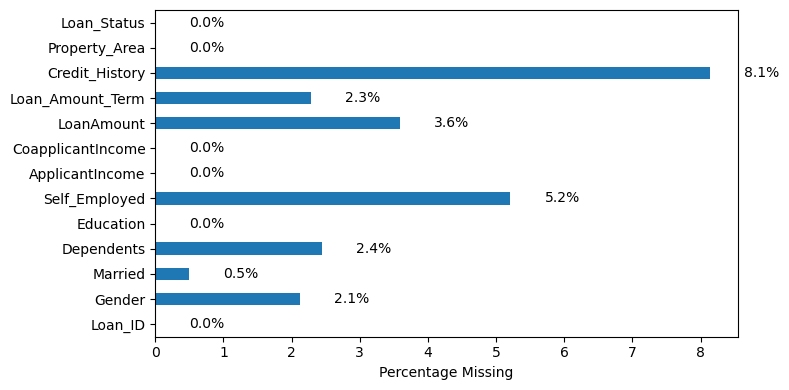

In [9]:
missing_report(df)

In [10]:
df['Property_Area']

0          Urban
1          Rural
2          Urban
3          Urban
4          Urban
         ...    
609        Rural
610        Rural
611        Urban
612        Urban
613    Semiurban
Name: Property_Area, Length: 614, dtype: object

In [11]:
df = df.dropna(subset=['Loan_Status'])

In [12]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [13]:
df.drop(columns=['Loan_ID'], inplace=True)

In [14]:
df['Credit_History'] = df['Credit_History'].astype('object')

In [15]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

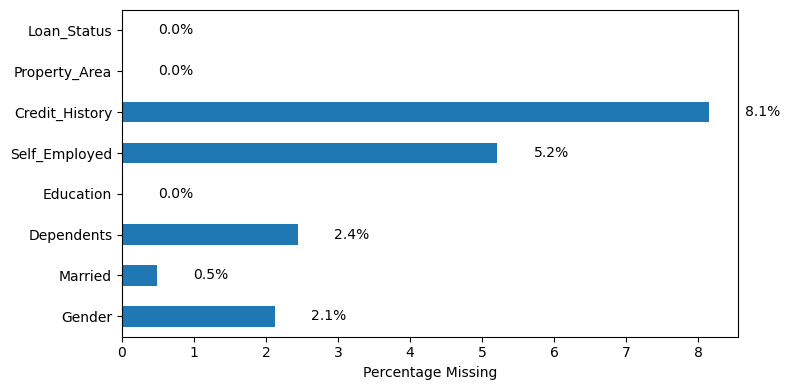

In [16]:
missing_report(df.select_dtypes(include='object'))

In [17]:
df['Gender'].mode()[0]

'Male'

In [18]:
# df['Gender'].fillna(df['Gender'].mode()[0]).isna().sum()
# help(df.fillna)

In [19]:
df['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [20]:
# For categorical values
df = df.fillna(value={
    'Property_Area': df['Property_Area'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'Education': df['Education'].mode()[0],
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    
    'Credit_History': df['Credit_History'].mode()[0],
})
df.isna().sum()

/var/folders/qc/blnpnyp9363472zrnqgw9r800000gn/T/ipykernel_77740/432975658.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(value={


Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [21]:
df['Credit_History'] = df['Credit_History'].astype('object')

/var/folders/qc/blnpnyp9363472zrnqgw9r800000gn/T/ipykernel_77740/2007673822.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


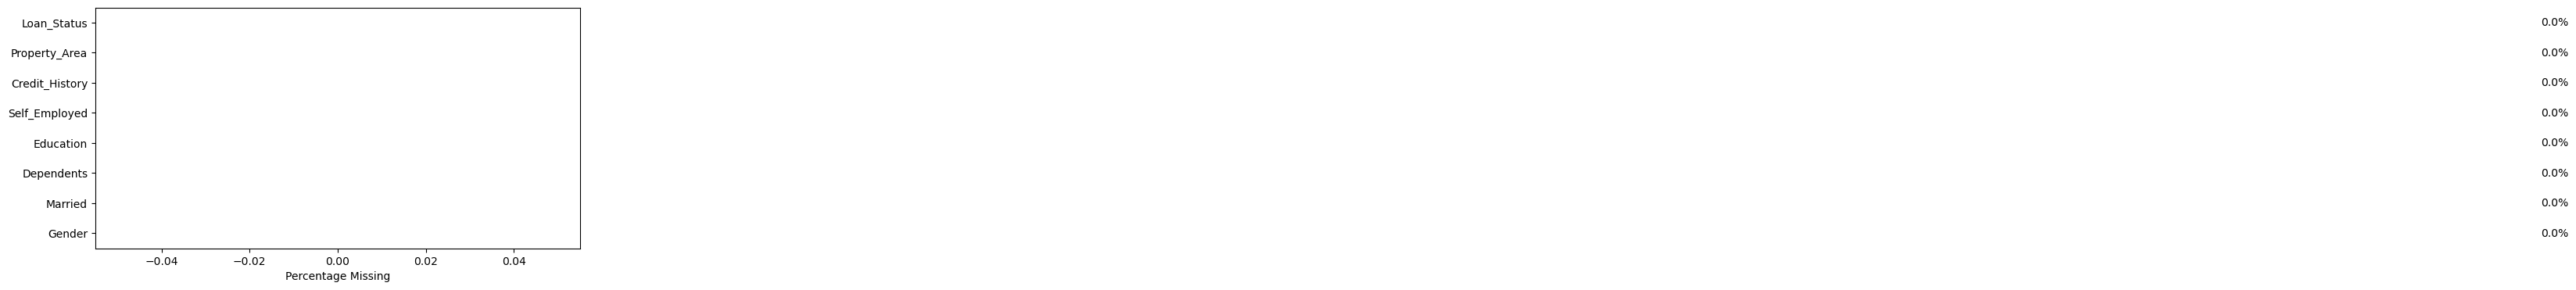

In [22]:
missing_report(df.select_dtypes(include='object'));

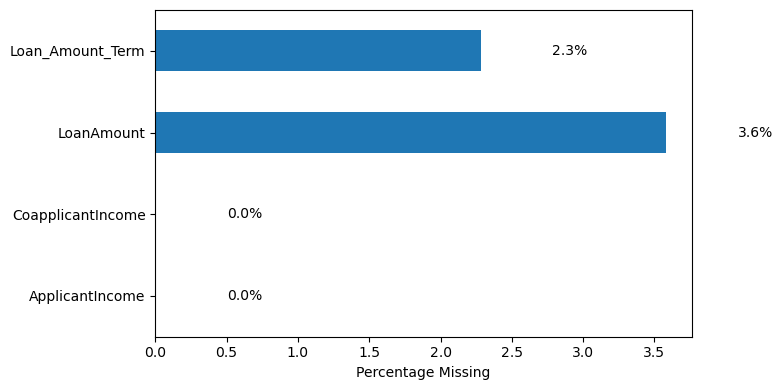

In [23]:
missing_report(df.select_dtypes(include='number'))

In [24]:
df = df.fillna(value={
    
    'Loan_Amount_Term': df['Loan_Amount_Term'].value_counts().mode()[0],
    
    'LoanAmount': df['LoanAmount'].mean(),
    'CoapplicantIncome': df['CoapplicantIncome'].mean(),
    'ApplicantIncome': df['ApplicantIncome'].mean()
})

/var/folders/qc/blnpnyp9363472zrnqgw9r800000gn/T/ipykernel_77740/2007673822.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


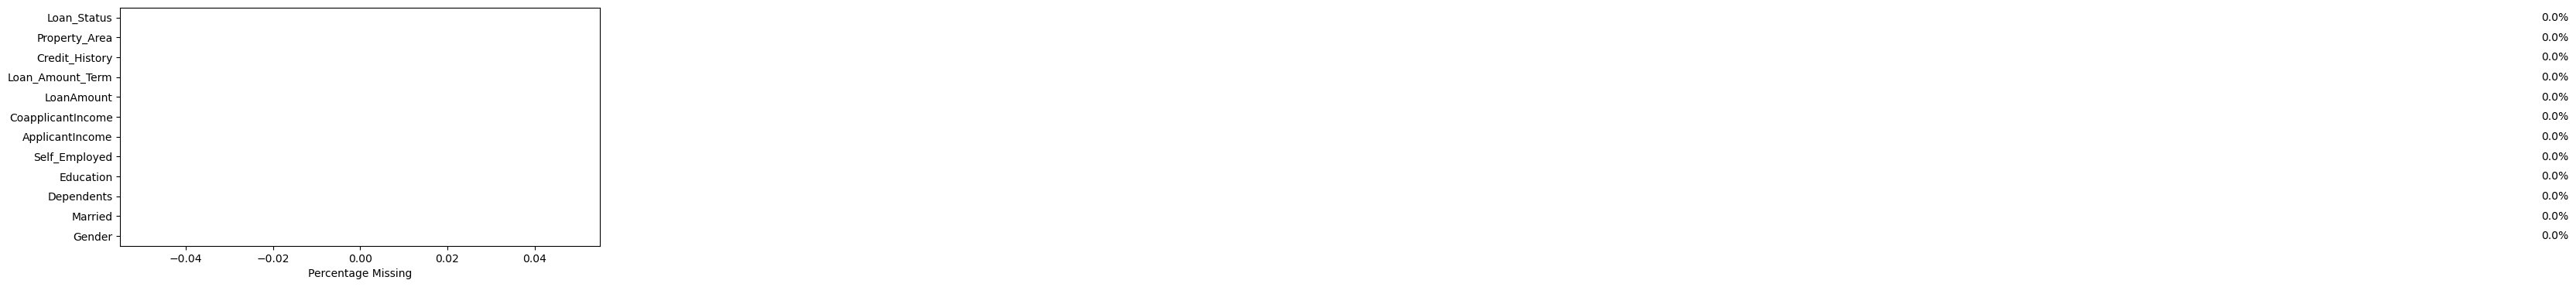

In [25]:
missing_report(df)

In [26]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [27]:
df['ApplicantIncome'] = df['ApplicantIncome'].astype('float')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    object 
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), object(8)
memory usage: 57.7+ KB


In [29]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,334.247557
std,6109.041673,2926.248369,84.037468,81.998472
min,150.000000,0.000000,9.000000,2.000000
25%,2877.500000,0.000000,100.250000,360.000000
50%,3812.500000,1188.500000,129.000000,360.000000
75%,5795.000000,2297.250000,164.750000,360.000000
max,81000.000000,41667.000000,700.000000,480.000000


In [30]:
df.select_dtypes(include='object').describe()

,Gender,Married,...,Property_Area,Loan_Status
count,614,614,...,614,614
unique,2,2,...,3,2
top,Male,Yes,...,Semiurban,Y
freq,502,401,...,233,422


<Axes: xlabel='Loan_Status', ylabel='count'>

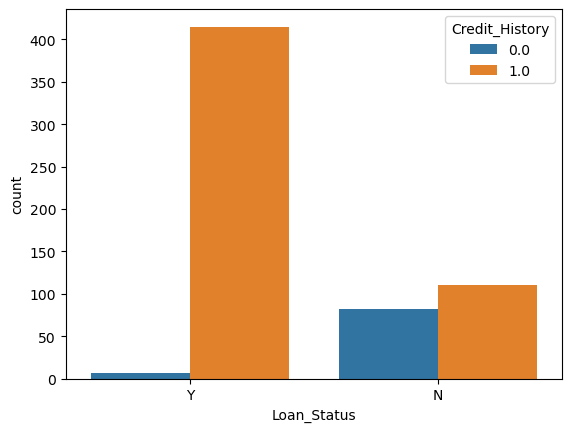

In [31]:
sns.countplot(df, x='Loan_Status', hue='Credit_History')

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

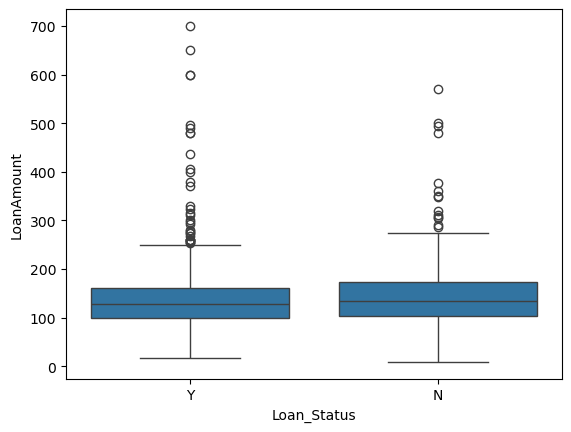

In [32]:
sns.boxplot(df, x='Loan_Status', y='LoanAmount')

<Axes: xlabel='Loan_Status', ylabel='count'>

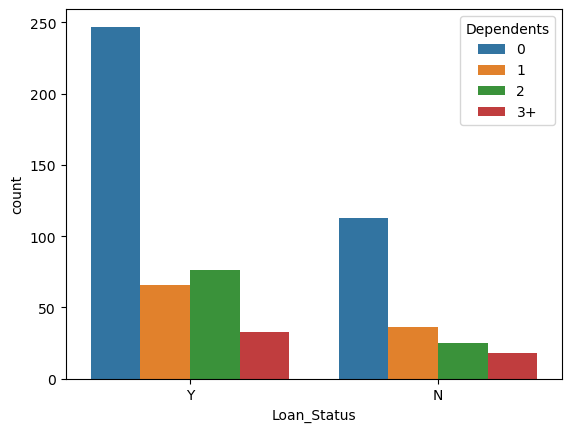

In [33]:
sns.countplot(df,x='Loan_Status', hue='Dependents')

<Axes: >

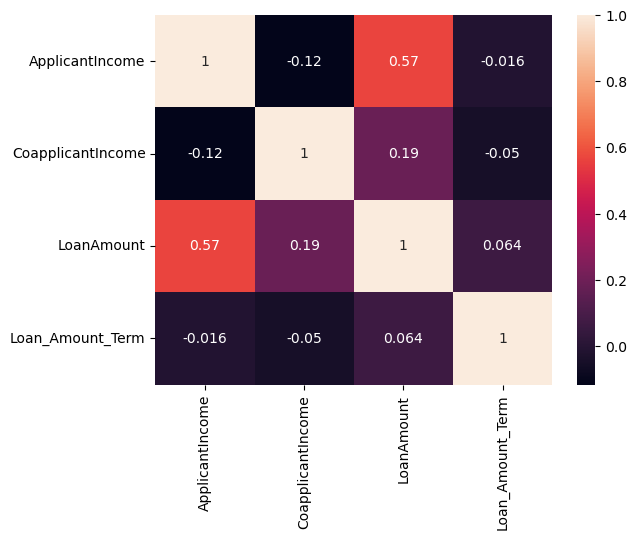

In [34]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True,)

In [35]:
df.to_csv('../data/processed/loan_cleaned.csv')

In [36]:
list(df.select_dtypes('object').columns)

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [37]:
df.iloc[0].to_json()

'{"Gender":"Male","Married":"No","Dependents":"0","Education":"Graduate","Self_Employed":"No","ApplicantIncome":5849.0,"CoapplicantIncome":0.0,"LoanAmount":146.4121621622,"Loan_Amount_Term":360.0,"Credit_History":1.0,"Property_Area":"Urban","Loan_Status":"Y"}'